# Inferência de núcleos sem retreinar

Este notebook recebe o caminho de uma imagem, carrega o checkpoint da Parte 2 e devolve uma máscara de instâncias colorida e a contagem. O exemplo abaixo usa uma imagem **do conjunto de teste** BBBC038: ela é do mesmo domínio das imagens de treinamento, mas não foi usada para ajustar os pesos. Execute o notebook na raiz do repositório. Para usar outra imagem, altere somente `IMAGE_PATH`; isso não muda os pesos nem os parâmetros do decoder. No Windows, use por exemplo `Path(r"C:\Users\...\imagem.png")`; no Colab, use um caminho visível no ambiente, como `/content/imagem.png`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from pa1_inference import colorize_instances, predict_file
from pa1_experiments import find_data_root

# Exemplo: imagem do BBBC038 reservada no conjunto de teste (seed 42).
# find_data_root usa as imagens já extraídas ou extrai o ZIP local uma vez.
DATA_ROOT = find_data_root(Path("data/BBBC038"))
IMAGE_ID = "003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1"
IMAGE_PATH = DATA_ROOT / IMAGE_ID / "images" / f"{IMAGE_ID}.png"
# Para testar uma imagem sua, substitua IMAGE_PATH por Path(r"C:\caminho\imagem.png").
CHECKPOINT_PATH = Path("checkpoints/small_unet_boundary_watershed_v2.pt")

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Defina IMAGE_PATH para uma imagem existente: {IMAGE_PATH}")
if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(f"Checkpoint não encontrado: {CHECKPOINT_PATH}")

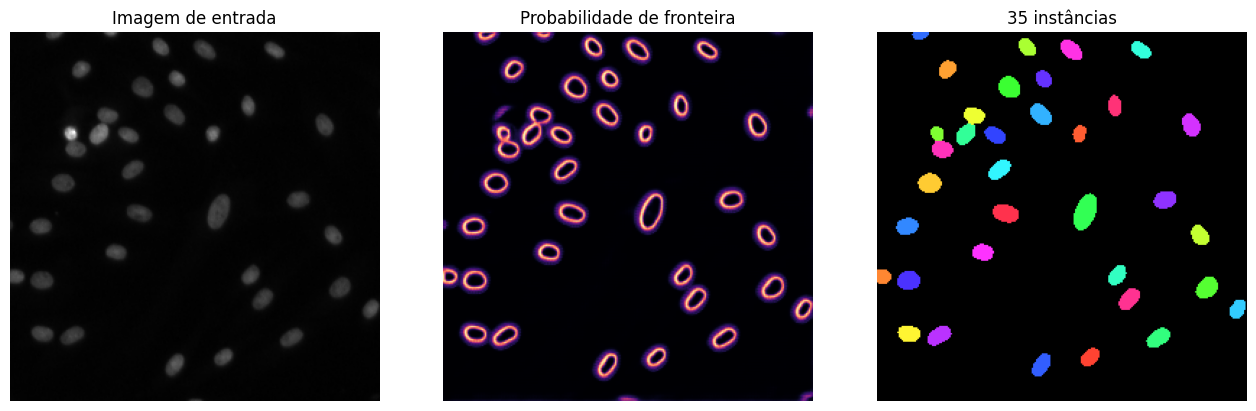

Contagem: 35
Máscara colorida salva em: C:\Users\julia\Documents\Projects\pa1-segmentacao-instancias\results\003cee89357d9fe13516167fd67b609a164651b21934585648c740d2c3d86dc1_instancias.png


In [2]:
image, instances, probabilities = predict_file(IMAGE_PATH, CHECKPOINT_PATH)
count = int(instances.max())
colored = colorize_instances(instances)

output_path = Path("results") / f"{IMAGE_PATH.stem}_instancias.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
Image.fromarray(colored).save(output_path)

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
axes[0].imshow(image, cmap="gray")
axes[0].set_title("Imagem de entrada")
axes[1].imshow(probabilities[2], cmap="magma")
axes[1].set_title("Probabilidade de fronteira")
axes[2].imshow(colored)
axes[2].set_title(f"{count} instâncias")
for axis in axes:
    axis.axis("off")
plt.show()
print("Contagem:", count)
print("Máscara colorida salva em:", output_path.resolve())